# CS251/2: Data Analysis and Visualization

## Multiple Linear Regression

Spring 2026

Oliver W. Layton

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [2]:
from data import Data

## Load in Waffle House data

[Waffle House Index Red](https://www.nbcnews.com/news/us-news/coronavirus-waffle-house-index-red-restaurant-chain-shutters-356-stores-n1168391)

CSV filename: `WaffleDivorce.csv`

In [3]:
waffle = Data('data/WaffleDivorce.csv')
print(waffle)

-------------------------------
data/WaffleDivorce.csv (50x8)
Headers:
  Population	MedianAgeMarriage	Marriage	Marriage SE	Divorce	Divorce SE	WaffleHouses	South
-------------------------------
Showing first 5/50 rows.
4.78	25.3	20.2	1.27	12.7	0.79	128.0	1.0
0.71	25.2	26.0	2.93	12.5	2.05	0.0	0.0
6.33	25.8	20.3	0.98	10.8	0.74	18.0	0.0
2.92	24.3	26.4	1.7	13.5	1.22	41.0	1.0
37.25	26.8	19.1	0.39	8.0	0.24	0.0	0.0

-------------------------------


## 1. Warm-up: Simple linear regression

Let's do a simple linear regression to quantify the association between:
- Number of Waffle House diners per million people in a state
- 2009 divorce rate in each state

Let's try and predict **divorce rate** from **number of Waffle Houses**.

Linear regression model:

$$y = c_0 + c_1x_1$$

What is $x_1$?

What role do $c_0$ and $c_1$ play here?

We need to determine $A$ and $\vec{y}$ to solve for $\vec{c}$: $$\vec{y} = A\vec{c}$$

In [4]:
x = waffle.select_data(['WaffleHouses'])
y = waffle.select_data(['Divorce'])

In [5]:
A = np.hstack([np.ones([len(x), 1]), x])

In [6]:
c, _, _, _ = scipy.linalg.lstsq(A, y)
c

array([[9.46023124e+00],
       [7.04294245e-03]])

Let's draw the regression line!

In [7]:
x_line = np.linspace(np.min(x), np.max(x))
y_line = c[0] + c[1]*x_line

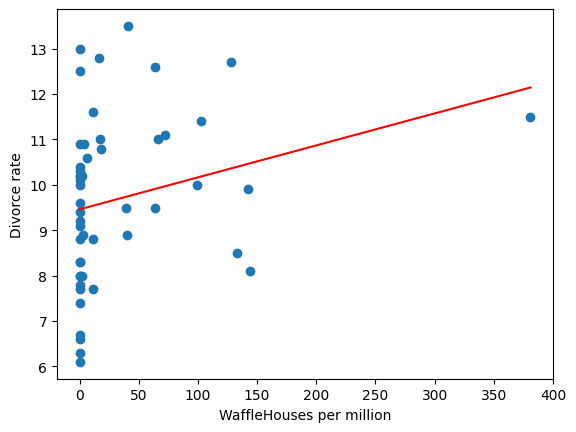

In [8]:
plt.scatter(x, y)
plt.plot(x_line, y_line, c='r')
plt.xlabel('WaffleHouses per million')
plt.ylabel('Divorce rate')
plt.show()

What do you make of the results?

MSE: 3.04

R^2: 0.065

## 2. Predict number of divorce rate from two independent variables

Let's fit a linear regression model (**multiple linear regression**) predict divorce rate from:

- Population
- MedianAgeMarriage

Independent variables? Dependent variables?

In [9]:
waffle.get_headers()

['Population',
 'MedianAgeMarriage',
 'Marriage',
 'Marriage SE',
 'Divorce',
 'Divorce SE',
 'WaffleHouses',
 'South']

Let's follow the same steps to set this up:

$$y = c_0 + c_1x_1 + c_2x_2$$

What variables do you want to define as $x_1$ and $x_2$?

Let's solve for $c$:

**Good news:** We don't need to change hardly anything when solving the least squares problem when adding more than 1 independent variable!

In [10]:
x = waffle.select_data(['Population', 'MedianAgeMarriage'])
y = waffle.select_data(['Divorce'])

A = np.hstack([np.ones([len(x), 1]), x])

c, _, _, _ = scipy.linalg.lstsq(A, y)
c

array([[31.59532513],
       [-0.03908454],
       [-0.83166283]])

Unlike the simple linear regression case, we cannot plot the regression curve in a 2D scatter plot because with 2 independent variables now, there are 3 total variables (2 independent + 1 dependent). So this would require a 3D scatter plot. What we can do (regardless of number of independent variables) is make a scatter plot showing the residuals (`y_true` - `y_pred`) for each of the 50 samples (states).

This gives us an intuitive sense of how well the regression model fits the data (i.e. error for each data sample used to fit the linear regression).

In [13]:
x.shape

(50, 2)

(50,)
(50,)


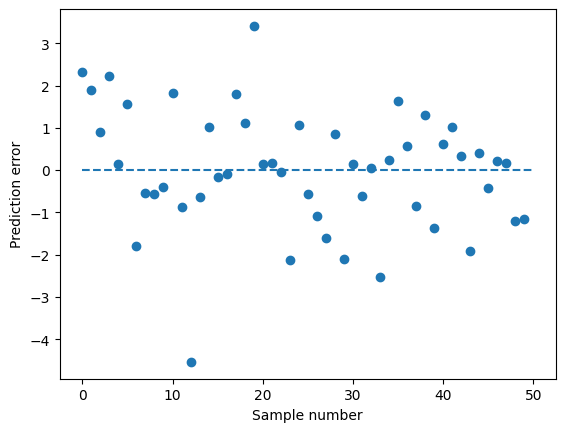

In [16]:
y_true = np.squeeze(y)
y_preds = c[0] + c[1]*x[:, 0] + c[2]*x[:, 1]
print(y_true.shape)
print(y_preds.shape)
errors = y_true - y_preds
x_values_plt = np.arange(len(y))
plt.scatter(x_values_plt, errors)
plt.hlines(xmin=0, xmax=len(x_values_plt), y=0, linestyles='dashed')
plt.xlabel('Sample number')
plt.ylabel('Prediction error')
plt.show()

## 3. Moving around the intercept term

Let's redo the same fit multiple linear regression (predict divorce rate from Population and MedianAgeMarriage), but this time for practice let's reorder the linear regression model slope and intercept:

$$y = c_0x_0 + c_1x_1 + c_2$$

We should get the same results, but we must interpret the coefficients differently!

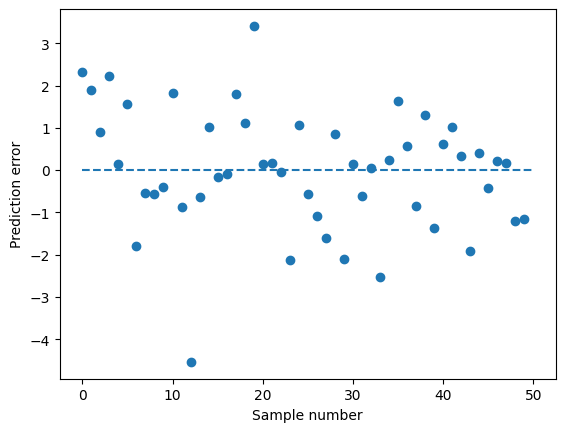

In [18]:
x = waffle.select_data(['Population', 'MedianAgeMarriage'])
y = waffle.select_data(['Divorce'])

A = np.hstack([x, np.ones([len(x), 1])])

c, _, _, _ = scipy.linalg.lstsq(A, y)
c

y_true = np.squeeze(y)
y_preds = c[0]*x[:, 0] + c[1]*x[:, 1] + c[2]

errors = y_true - y_preds
x_values_plt = np.arange(len(y))
plt.scatter(x_values_plt, errors)
plt.hlines(xmin=0, xmax=len(x_values_plt), y=0, linestyles='dashed')
plt.xlabel('Sample number')
plt.ylabel('Prediction error')
plt.show()